In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


(array([117938.,  33034.,  20060.,  13791.,  10177.,   7853.,   6407.,
          4520.,   4535.,   3269.,   2933.,   2156.,   3036.,   1998.,
          1686.,   1426.,   1280.,   1015.,   1410.,   1152.,   1060.,
          1167.,    878.,    851.,    891.,    901.,    635.,    385.,
           491.,    501.,    446.,    468.,    471.,    511.,    580.,
           353.,    268.,    348.,    277.,    212.,    229.,    360.,
           399.,    272.,    129.,    137.,    165.,    172.,    306.,
           247.]),
 array([  1.  ,  16.16,  31.32,  46.48,  61.64,  76.8 ,  91.96, 107.12,
        122.28, 137.44, 152.6 , 167.76, 182.92, 198.08, 213.24, 228.4 ,
        243.56, 258.72, 273.88, 289.04, 304.2 , 319.36, 334.52, 349.68,
        364.84, 380.  , 395.16, 410.32, 425.48, 440.64, 455.8 , 470.96,
        486.12, 501.28, 516.44, 531.6 , 546.76, 561.92, 577.08, 592.24,
        607.4 , 622.56, 637.72, 652.88, 668.04, 683.2 , 698.36, 713.52,
        728.68, 743.84, 759.  ]),
 <BarContainer obj

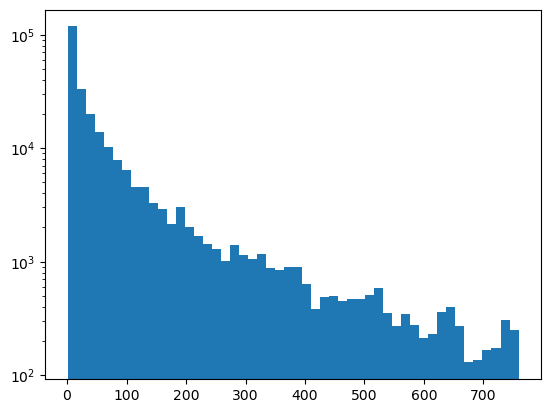

In [2]:
lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

plt.hist(lofcorr_df['top_plof_var_count'], bins=50, log=True)

In [3]:
# Read the full Genebass results
pval_cutoffs = {'burden': 6.7e-7, 'skato': 2.5e-7}

# Convert the pandas operations into a single Polars expression
gb_pl = (
    pl.read_parquet('/home/dnanexus/data_dir/association_files/genebass_all_associations_p_e-5.parquet')
    .with_columns(
        significant = (pl.col('Pvalue') < pval_cutoffs['skato']) | (pl.col('Pvalue_Burden') < pval_cutoffs['burden']),
        phenotype = pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.replace_all('-', '').str.replace_all("'", '').str.replace_all(',', '').str.to_lowercase() + '_int',
        region = pl.col('gene_id'),
        gene_name = pl.col('gene_symbol'),
    )
    .filter(
        (pl.col('significant') == True) &
        (pl.col('trait_type') == 'continuous') &
        # (pl.col('annotation').str.contains('pLoF'))
        (pl.col('annotation') == 'pLoF')
    )
    .select(['region', 'gene_name', 'phenotype', 'trait_type'])
    .unique()
)

gene_trait_df = gb_pl[['region', 'gene_name', 'phenotype', 'trait_type']].unique()

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)
gene_trait_df = gb_pl.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner')

lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

gene_trait_df = gene_trait_df.join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='left').with_columns(
    sign_agreement = (pl.col('loftee_corr')*pl.col('beta') > 0) & (pl.col('loftee_corr').is_not_nan()),
    corr_dir = (pl.col('loftee_corr')/pl.col('loftee_corr').abs())
)

# TODO: We don't cover all genebass significant genes, so we need to filter out nans (LOFTEE correlations missing)
# gene_trait_df = gene_trait_df.filter(pl.col('sign_agreement')==1)
gene_trait_df

region,gene_name,phenotype,trait_type,beta,rvat_pval,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,sign_agreement,corr_dir
str,str,str,str,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64,bool,f32
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""","""continuous""",-0.195409,9.1637e-8,1280,1280,70,-0.129833,"[62, 54, … 1]","""chr1:176710105:CG:C""",62,0.0546875,-4.681031,0.000003,true,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""","""continuous""",-0.397279,0.006626,530,530,13,-0.219682,"[1, 1, … 1]","""chr11:14493694:G:A""",1,0.024528,-5.174315,3.2549e-7,true,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""","""continuous""",-0.058463,0.000305,1098,1098,106,-0.036752,"[627, 129, … 1]","""chr14:58428357:T:TC""",627,0.096539,-1.217545,0.223659,true,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""","""continuous""",-0.436618,6.0395e-11,2030,2030,55,-0.199516,"[40, 37, … 1]","""chr15:88843601:CG:C""",40,0.027094,-9.169199,1.1354e-19,true,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""","""continuous""",-0.412619,2.8609e-8,1093,1093,46,-0.154286,"[13, 7, … 1]","""chr15:98924680:CAA:C""",13,0.042086,-5.157856,2.9651e-7,true,-1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""","""continuous""",0.952411,1.8038e-41,315,315,16,0.174576,"[149, 5, … 1]","""chr6:49636655:C:T""",149,0.050794,3.136737,0.001871,true,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""","""continuous""",0.656849,2.1682e-10,1392,1392,34,0.269449,"[18, 12, … 1]","""chr8:41672574:CTG:C""",18,0.024425,10.431616,1.3985e-24,true,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""","""continuous""",0.176348,2.1188e-7,2047,2047,225,0.035972,"[109, 67, … 1]","""chr9:77339540:C:CT""",109,0.109917,1.627776,0.103726,true,1.0


In [4]:
a = gene_trait_df[['phenotype', 'gene_name', 'region', 'top_plof_var', 'top_plof_var_count']].group_by('gene_name').agg(
    pl.col('top_plof_var').n_unique(),
    pl.col('top_plof_var_count').n_unique()
).sort('top_plof_var', descending=True)

a.filter(pl.col('top_plof_var') > 1)

gene_name,top_plof_var,top_plof_var_count
str,u64,u64
"""RRM1""",3,1
"""RORC""",3,1
"""TRIM40""",2,3
"""RIF1""",2,2
"""SLC22A2""",2,2
…,…,…
"""NPR2""",2,2
"""PLIN1""",2,4
"""PDE3B""",2,10


## Plot single gene-trait assoc

In [ ]:
# --- 1. Read anngeno and get genotypes ---
ag = AnnGeno('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag', low_mem=True)

phenotype = 'ldl_direct_int'
gene_name = 'LDLR'

gtdf = gene_trait_df.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
)
gene_id = gtdf['region'].unique().item()
gdata = ag.get_many_regions([gene_id])[gene_id]

# --- 2. Drop top plof variant and compute burdens ---
tpv = gtdf['top_plof_var'].item()
indices = np.where(gdata['variant_ids'] == tpv)[0]

gdata['genotypes'] = np.delete(gdata['genotypes'], indices, axis=0)
gdata['annotations'] = gdata['annotations'].filter(pl.col('id')!=tpv)

plof_burdens = pl.DataFrame({
    'individual': ag.samples,
    'burden': gdata['genotypes'].T @ gdata['annotations']['loftee_hc'].to_numpy()
})#.filter(pl.col('burden') < 2)

# --- 2. Read and merge data ---
config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
cov_list = config.get("covariates", [])

pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'

pheno_lazy = pl.scan_parquet(pheno_path).select("IID", phenotype).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
prs_lazy = pl.scan_parquet(prs_path).select("IID", f"{phenotype}_prs").rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
cov_lazy = pl.scan_parquet(cov_path).select("sample", *cov_list).rename({"sample": "individual"})

# Join everything and collect into a pandas DataFrame for the regression
merged_pd = (
    pheno_lazy
    .join(prs_lazy, on="individual", how="inner")
    .join(cov_lazy, on="individual", how="inner")
    .drop_nulls()
    .drop_nans()
    .collect()
    .to_pandas()
)

# --- 3. Compute residuals for the single phenotype ---
# Define the dependent (y) and independent (X) variables
y = merged_pd[phenotype]
X = merged_pd[[f"{phenotype}_prs"] + cov_list]
X = sm.add_constant(X) # Add an intercept

# Fit the linear model and get the residuals
model = sm.OLS(y, X).fit()
residuals = model.resid

# --- 4. Create the final long-format DataFrame ---
p_df = pl.DataFrame({
    "individual": merged_pd["individual"].astype(str),
    "phenotype": phenotype,
    "pheno_value": residuals
})

# 4. Join with gene burdens
plot_gp_df = plof_burdens.join(p_df, on='individual', how='inner')
print('Number of plofs:', plot_gp_df['burden'].sum())

plot_gp_df

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


Number of plofs: 85


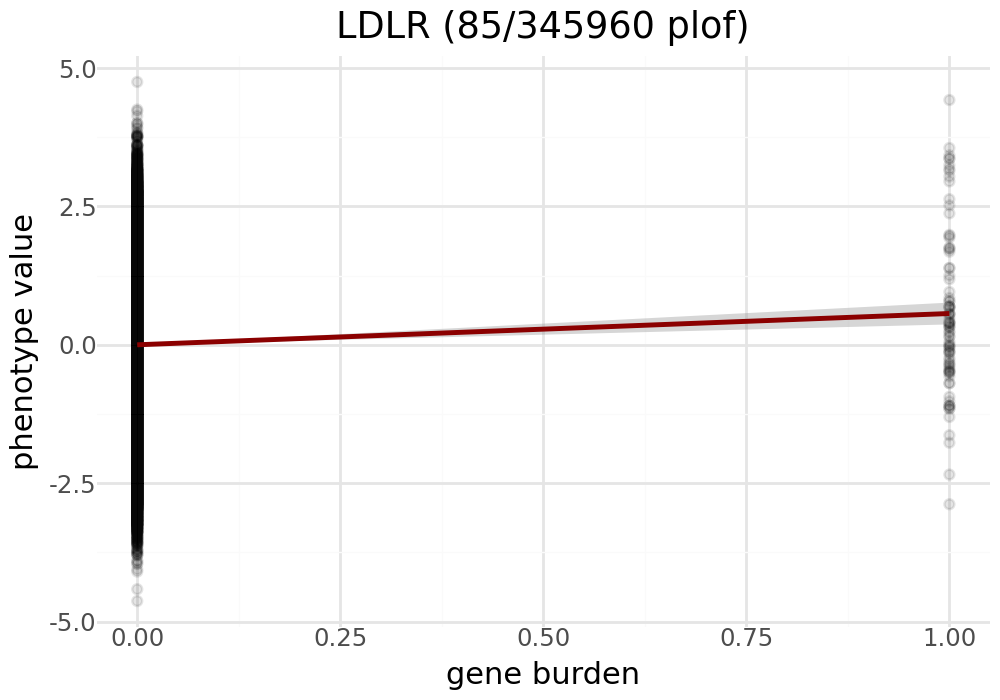

In [51]:
(
    ggplot(plot_gp_df, aes(x='burden', y='pheno_value')) +
    geom_point(alpha=0.1) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x='gene burden',
        y="phenotype value",
        title=f"{gene_name} ({plot_gp_df['burden'].sum()}/{plot_gp_df.shape[0]} plof)"
    ) +
    theme(figure_size=(5, 3.5))
)

## Get p-values across all associations

In [5]:
config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
cov_list = config.get("covariates", [])

pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'

pheno_lazy = pl.scan_parquet(pheno_path).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
prs_lazy = pl.scan_parquet(prs_path).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
cov_lazy = pl.scan_parquet(cov_path).select("sample", *cov_list).rename({"sample": "individual"})

ag = AnnGeno('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag', low_mem=True)

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


In [ ]:
# gene_id = 'ENSG00000130164'
rvat_df_list = []
for gene_id in tqdm(gene_trait_df['region'].unique().to_list()):
    gdata = ag.get_many_regions([gene_id])[gene_id]
    gene_name = gene_trait_df.filter(pl.col('region') == gene_id)['gene_name'].unique().item()

    pheno_list = gene_trait_df.filter(pl.col('region') == gene_id)['phenotype'].to_list()
    for phenotype in tqdm(pheno_list):
        gtdf = gene_trait_df.filter(
            (pl.col('phenotype') == phenotype) &
            (pl.col('region') == gene_id)
        )
        if gtdf['n_plof_variants'].item() > 1:
            tpv = gtdf['top_plof_var'].item()
            indices = np.where(gdata['variant_ids'] == tpv)[0]
            plof_burdens = pl.DataFrame({
                'individual': ag.samples,
                'burden': np.delete(gdata['genotypes'], indices, axis=0).T @ gdata['annotations'].filter(pl.col('id')!=tpv)['loftee_hc'].to_numpy()
            })#.filter(pl.col('burden') < 2)

            # Join everything and collect into a pandas DataFrame for the regression
            merged_pd = (
                pheno_lazy.select("individual", phenotype)
                .join(plof_burdens.lazy(), on="individual", how="inner")
                .join(prs_lazy.select("individual", f"{phenotype}_prs"), on="individual", how="inner")
                .join(cov_lazy, on="individual", how="inner")
                .drop_nulls()
                .drop_nans()
                .collect(engine='streaming')
            )

            # --- 3. Compute residuals for the single phenotype ---
            y = merged_pd[phenotype].to_numpy()
            X = merged_pd[["burden", f"{phenotype}_prs"] + cov_list].to_numpy()
            X = sm.add_constant(X) # Add an intercept

            # Fit the linear model and get the residuals
            model = sm.OLS(y, X).fit()
            pval = model.pvalues[1]
            beta = model.params[1]
            n_plofs = int(plof_burdens['burden'].sum())

        else:
            pval = np.nan
            beta = np.nan
            n_plofs = 0

        rvat_df_list.append(pl.DataFrame({
            "phenotype": phenotype,
            "gene_name": gene_name,
            "region": gene_id,
            "p_value": pval,
            "beta": beta,
            "n_variants": gtdf['n_variants'].item(),
            "n_plofs": n_plofs,
            "dropped_plof_count": gtdf['top_plof_var_count'].item(),
            "dropped_plof": gtdf['top_plof_var'].item(),
        }))

rvat_wo_top_plof = pl.concat(rvat_df_list)
rvat_wo_top_plof

  4%|▍         | 15/394 [02:50<1:07:37, 10.71s/it]